In [6]:
import numpy as np
import matplotlib.pyplot as plt
from Eigenvalue_problems import QR_eigenvalues

In [7]:
def H_ring (N, A, B, alpha, mr) :
    K = np.zeros((N, N))
    np.fill_diagonal(K, -2)
    U = np.zeros((N, N))
    I = np.eye(N)

    for i in range (N-1) :
        K[i+1, i] = 1
        K[i, i+1] = 1
        
        U[i+1, i] = -1
        U[i, i+1] = 1

    K[N-1, 0] = A
    K[0, N-1] = B

    U[N-1, 0] = A
    U[0, N-1] = -B

    h = -(N**2)/(8*np.pi**2 * mr**2) * K -1j*alpha*N/(4*np.pi*mr**2) * U + alpha**2/(2*mr**2) * I

    return h

In [8]:
N_theta = 128
dtheta = 2 * np.pi / N_theta

A = 1
B = 1
mr = 1

alpha = 0.5

epsilon = 1e-6
n_iter = 100

H = H_ring(N_theta, A, B, alpha, mr)

eigvals = QR_eigenvalues(H, epsilon, n_iter)[0]
eigvals_sorted = np.sort(eigvals)[:7]  # i 7 autovalori più bassi

l_range = np.arange(-4, 5)
E_exact = 1/(2*mr**2) * (l_range + alpha)**2
E_exact_sorted = np.sort(E_exact)[:7]

print("Autovalori numerici (i più bassi):", np.round(eigvals_sorted, 5))
print("Autovalori esatti   (i più bassi):", np.round(E_exact_sorted, 5))
print("Differenza massima:", np.max(np.abs(eigvals_sorted - E_exact_sorted)))

Autovalori numerici (i più bassi): [0.12505-0.j 0.12505+0.j 1.12485+0.j 1.12485-0.j 3.12203-0.j 3.12204-0.j
 6.1118 -0.j]
Autovalori esatti   (i più bassi): [0.125 0.125 1.125 1.125 3.125 3.125 6.125]
Differenza massima: 0.01319643894953515


Confronto autostato fondamentale al variare di alpha

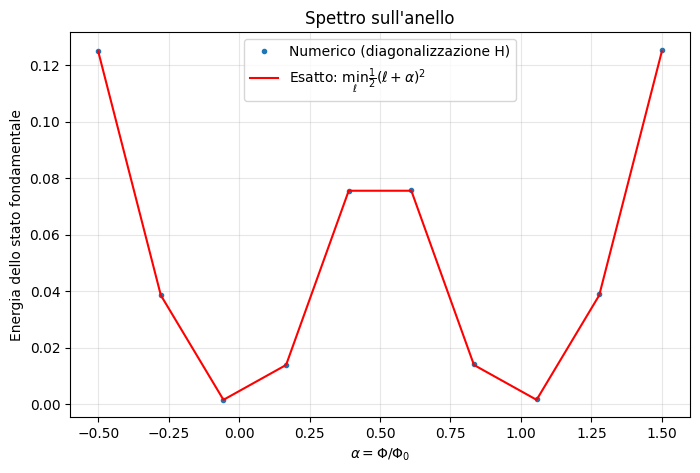

In [9]:
alpha_scan = np.linspace(-0.5, 1.5, 10)
ground_state_energy = []

for alpha in alpha_scan:
    H = H_ring(N_theta, A, B, alpha, mr)
    eigvals = QR_eigenvalues(H, epsilon, n_iter)[0]
    ground_state_energy.append(np.min(eigvals))

ground_state_energy = np.array(ground_state_energy)

E_ground_exact = np.array([min(1/(2*mr**2)*(l + a)**2 for l in range(-3, 4)) for a in alpha_scan])

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(alpha_scan, ground_state_energy, 'o', ms=3, label='Numerico (diagonalizzazione H)')
ax.plot(alpha_scan, E_ground_exact, '-', color='red', label='Esatto: $\\min_\\ell \\frac{1}{2}(\\ell+\\alpha)^2$')
ax.set_xlabel(r'$\alpha = \Phi/\Phi_0$')
ax.set_ylabel('Energia dello stato fondamentale')
ax.set_title('Spettro sull\'anello')
ax.legend()
ax.grid(alpha=0.3)
plt.show()